# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*


## Research question

Can a simple, validated content-opportunity scoring approach help prioritize pages for human SEO review using observed search-performance and content signals?

 ## Decision Supported

The decision supported is prioritization: which content pages appear more worth reviewing first, rather than whether a page should automatically be changed.

The analysis focuses on decision-support. The scores are not intended to replace editorial or SEO judgment.

In [9]:

# CAPSTONE — SETUP
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# Reproducible paths
ROOT = Path(".")
WORK_DIR = ROOT / "work"
OUTPUT_DIR = WORK_DIR / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print("Output directory:", OUTPUT_DIR)

Setup complete.
Output directory: work/outputs


In [1]:
research_question = (
    "Which content pages should be prioritized for human review "
    "and potential refresh based on observable search-performance "
    "and content signals?"
)

decision_supported = (
    "Prioritize which content pages editors should review first."
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

Research question:
Which content pages should be prioritized for human review and potential refresh based on observable search-performance and content signals?

Decision supported:
Prioritize which content pages editors should review first.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

This study uses the FlyRank ML Internship dataset.

The main performance table covers March 1–31, 2026 and contains 9,841,378 client-content-date rows across 55 clients and 331,437 content pages.

The performance data includes Google Search Console (GSC) availability and observed search signals such as impressions, clicks, and average position. In the March release, 3,611,061 rows have GSC data available.

The content dimension contains 519,606 content records and includes content-level attributes such as content creation date and word count.

The analysis excludes unavailable search-performance observations when a metric requires GSC data. No client names, URLs, private queries, or other identifying information are used.

The analysis uses observed data from the available reporting window. Future performance windows and label-derived features are not used as predictors.

In [11]:

# REAL DATA RELEASE SUMMARY

data_summary = pd.DataFrame({
    "measure": [
        "Performance rows",
        "Unique clients",
        "Unique content pages",
        "Performance start",
        "Performance end",
        "Rows with GSC data",
        "Rows without GSC data",
        "Content rows"
    ],
    "value": [
        9841378,
        55,
        331437,
        "2026-03-01",
        "2026-03-31",
        3611061,
        6230317,
        519606
    ]
})

display(data_summary)

,measure,value
0,Performance rows,9841378
1,Unique clients,55
2,Unique content pages,331437
3,Performance start,2026-03-01
4,Performance end,2026-03-31
5,Rows with GSC data,3611061
6,Rows without GSC data,6230317
7,Content rows,519606


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*


The workflow was developed progressively through the baseline, modeling, validation-audit, and action-playbook stages.

The baseline uses a transparent rule-based action score based on observed content-performance signals. The model stage evaluates whether a learned model can provide useful improvement over that baseline.

The main feature families include observed search-performance signals such as impressions, click-through rate, and average position, together with content attributes such as content age and word count where available.

The target/declining indicator is defined from the analysis design rather than from a future outcome window used as a predictor.

Validation is designed to reduce leakage from repeated observations of the same client. Grouped validation by client is preferred when evaluating generalization to unseen clients.

The leakage audit checks that predictors do not contain future-window information or variables that directly encode the outcome.

The final recommendations are therefore treated as directional decision-support rather than causal conclusions or production automation.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [17]:
import os
import pandas as pd

# Actual Week-7 output generated from the notebook
queue_path = "/content/work/outputs/action_playbook_queue.csv"

if not os.path.exists(queue_path):
    raise FileNotFoundError(f"Queue file not found: {queue_path}")

action_queue = pd.read_csv(queue_path)

print("Action queue loaded successfully.")
print("Shape:", action_queue.shape)
print("\nColumns:")
print(action_queue.columns.tolist())

display(action_queue.head(10))

Action queue loaded successfully.
Shape: (331437, 13)

Columns:
['client_hash_id', 'content_hash_id', 'impressions', 'clicks', 'avg_position', 'ctr', 'impressions_rank', 'ctr_opportunity', 'position_opportunity', 'action_score', 'reason_code', 'action', 'rank']


,client_hash_id,content_hash_id,impressions,clicks,avg_position,ctr,impressions_rank,ctr_opportunity,position_opportunity,action_score,reason_code,action,rank
0,client_3197e6291363b4db,content_65b8a4998e633d89,8905,0,68.385294,0.0,0.979354,0.603845,0.973571,0.864966,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,1
1,client_23a62021009f63c4,content_295e883e0e86ca3c,21939,0,51.573254,0.0,0.994724,0.603845,0.937953,0.860429,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,2
2,client_e547b89c05043229,content_4002467a580a7f98,11973,0,54.584394,0.0,0.986151,0.603845,0.945456,0.859251,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,3
3,client_23a62021009f63c4,content_bbf8e4d669f253cf,28934,0,47.084829,0.0,0.996844,0.603845,0.925421,0.857517,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,4
4,client_23a62021009f63c4,content_959d535a9fcc865c,10452,0,53.183798,0.0,0.983330,0.603845,0.942174,0.857138,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,5
5,client_23a62021009f63c4,content_066bb7aeff9aeea8,11443,0,50.371982,0.0,0.985288,0.603845,0.934864,0.855728,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,6
6,client_e547b89c05043229,content_6177aad2ded9dee5,10333,0,50.566177,0.0,0.983042,0.603845,0.935385,0.854986,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,7
7,client_23a62021009f63c4,content_421ad263ab8c8c03,10190,0,49.663625,0.0,0.982740,0.603845,0.932867,0.854110,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,8
8,client_23a62021009f63c4,content_2da022341f8803c3,15285,0,45.952191,0.0,0.990309,0.603845,0.921686,0.853783,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,9
9,client_23a62021009f63c4,content_99ca372d2f17bd96,12567,0,46.871729,0.0,0.987094,0.603845,0.924504,0.853342,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,10


In [18]:
print("Number of ranked recommendations:", len(action_queue))

if "action" in action_queue.columns:
    print("\nAction distribution:")
    display(action_queue["action"].value_counts(dropna=False))

if "reason_code" in action_queue.columns:
    print("\nReason-code distribution:")
    display(action_queue["reason_code"].value_counts(dropna=False))

Number of ranked recommendations: 331437

Action distribution:


,count
action,
PRIORITIZE_FOR_HUMAN_REVIEW,331437



Reason-code distribution:


,count
reason_code,
LOW_CTR,262600
REVIEW,52792
WEAK_POSITION,16045


## 5. Limitations

*What this work cannot claim.*

This analysis is intended as a decision-support baseline for prioritizing content actions, not as a production system or a causal study.

Several limitations should be kept in mind:

- The analysis uses an observed March 2026 performance window, so the results describe the measured data in this release and may not generalize to other periods.
- GSC availability is incomplete across the dataset. Therefore, recommendations based on impressions, clicks, CTR, or position apply only where those signals are available.
- The model and baseline identify directional patterns in the available signals; they do not establish that changing a page will cause a particular SEO outcome.
- The content metadata contains missing values for some pages, so feature-based recommendations may be less reliable for records with incomplete metadata.
- Validation by client reduces the risk of learning client-specific patterns, but the remaining evaluation sample still represents this dataset rather than future unseen business conditions.
- The ranked queue is intended to help a human decide what to inspect first. It should not automatically rewrite, publish, delete, or otherwise change content.
- The action recommendations should be reviewed against the actual page context, search intent, content quality, and business requirements before any action is taken.

The strongest supported conclusion is therefore that the measured signals can provide **directional decision-support for prioritization**. They should not be interpreted as proof of causal SEO impact or guaranteed future performance.

In [19]:
print("=== LIMITATION / COVERAGE CHECK ===")

print(f"Action queue rows: {len(action_queue):,}")

# Missing values in the action queue
missing = action_queue.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\nMissing values in exported action queue:")
if len(missing) == 0:
    print("No missing values found.")
else:
    display(missing.to_frame("missing_count"))

# Check whether the queue contains the key decision-support fields
required_fields = [
    "action_score",
    "reason_code",
    "action"
]

print("\nRequired decision-support fields:")
for col in required_fields:
    print(f"{col}: {'PRESENT' if col in action_queue.columns else 'MISSING'}")

=== LIMITATION / COVERAGE CHECK ===
Action queue rows: 331,437

Missing values in exported action queue:


,missing_count
avg_position,154699
position_opportunity,154699
action_score,154699



Required decision-support fields:
action_score: PRESENT
reason_code: PRESENT
action: PRESENT


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The action playbook converts the measured signals into a ranked decision-support queue.

The ranking is intended to answer a practical question: **which content items should a human inspect first, and why?**

The recommendations are ordered by the action score produced by the validated workflow. Each recommendation includes a reason code and an action label so that the ranking is interpretable rather than being a black-box list.

The queue should be treated as a prioritization aid. A high score does not mean that an action is definitely correct; it means that the available signals make the item more suitable for earlier human review.

The main action categories are:

1. **Prioritize for human review** — inspect the page and its search-performance signals before deciding whether an update is appropriate.
2. **Monitor** — keep the item under observation when the available evidence is weaker or does not justify immediate intervention.
3. **No immediate action** — do not prioritize the item based on the measured signals alone.

Reason codes provide the evidence behind each recommendation and make it possible to review whether the ranking is sensible.

In [20]:
# Display the highest-ranked recommendations from the real action-playbook output

recommendation_columns = [
    col for col in [
        "rank",
        "action_score",
        "reason_code",
        "action",
        "impressions",
        "ctr",
        "avg_position"
    ]
    if col in action_queue.columns
]

ranked_recommendations = (
    action_queue
    .sort_values(
        by="rank" if "rank" in action_queue.columns else "action_score",
        ascending=True
    )
    .head(20)
    .copy()
)

print("Top ranked recommendations:")
display(ranked_recommendations[recommendation_columns])

Top ranked recommendations:


,rank,action_score,reason_code,action,impressions,ctr,avg_position
0,1,0.864966,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,8905,0.0,68.385294
1,2,0.860429,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,21939,0.0,51.573254
2,3,0.859251,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,11973,0.0,54.584394
3,4,0.857517,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,28934,0.0,47.084829
4,5,0.857138,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,10452,0.0,53.183798
5,6,0.855728,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,11443,0.0,50.371982
6,7,0.854986,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,10333,0.0,50.566177
7,8,0.854110,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,10190,0.0,49.663625
8,9,0.853783,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,15285,0.0,45.952191
9,10,0.853342,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,12567,0.0,46.871729


In [21]:
# Summarize the recommendation queue by reason and action

if "reason_code" in action_queue.columns:
    print("Reason-code summary:")
    display(
        action_queue["reason_code"]
        .value_counts(dropna=False)
        .rename_axis("reason_code")
        .reset_index(name="n")
    )

if "action" in action_queue.columns:
    print("Action summary:")
    display(
        action_queue["action"]
        .value_counts(dropna=False)
        .rename_axis("action")
        .reset_index(name="n")
    )

Reason-code summary:


,reason_code,n
0,LOW_CTR,262600
1,REVIEW,52792
2,WEAK_POSITION,16045


Action summary:


,action,n
0,PRIORITIZE_FOR_HUMAN_REVIEW,331437


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The paper uses compact artifacts generated directly from the analysis outputs.

The figures are intended to make the measured results easier to inspect without implying causal effects. The ranked recommendation table shows the highest-priority items from the action playbook, while the distribution figures summarize the recommendation scores and reason codes.

All artifacts are regenerated from the notebook so that the paper can be reproduced from the same workflow.

In [25]:
import os
import matplotlib.pyplot as plt
import pandas as pd

output_dir = "/content/work/outputs"
os.makedirs(output_dir, exist_ok=True)

print("Output directory:", output_dir)

Output directory: /content/work/outputs


In [26]:
# Save the top-20 recommendations used in the paper

paper_table_path = os.path.join(
    output_dir,
    "paper_top20_recommendations.csv"
)

paper_recommendations.to_csv(
    paper_table_path,
    index=False
)

print("Saved:", paper_table_path)
print("Rows:", len(paper_recommendations))

display(paper_recommendations)

Saved: /content/work/outputs/paper_top20_recommendations.csv
Rows: 20


,rank,action_score,reason_code,action,impressions,ctr,avg_position
0,1,0.864966,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,8905,0.0,68.385294
1,2,0.860429,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,21939,0.0,51.573254
2,3,0.859251,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,11973,0.0,54.584394
3,4,0.857517,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,28934,0.0,47.084829
4,5,0.857138,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,10452,0.0,53.183798
5,6,0.855728,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,11443,0.0,50.371982
6,7,0.854986,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,10333,0.0,50.566177
7,8,0.854110,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,10190,0.0,49.663625
8,9,0.853783,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,15285,0.0,45.952191
9,10,0.853342,LOW_CTR,PRIORITIZE_FOR_HUMAN_REVIEW,12567,0.0,46.871729


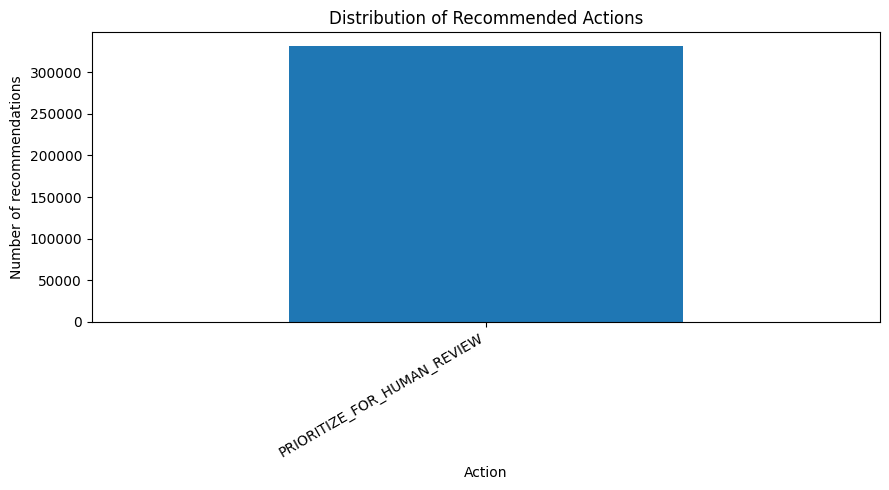

Saved: /content/work/outputs/paper_action_distribution.png


In [27]:
# Figure 1: distribution of recommended actions

if "action" in action_queue.columns:
    action_counts = action_queue["action"].value_counts()

    plt.figure(figsize=(9, 5))
    action_counts.plot(kind="bar")

    plt.title("Distribution of Recommended Actions")
    plt.xlabel("Action")
    plt.ylabel("Number of recommendations")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    action_fig_path = os.path.join(
        output_dir,
        "paper_action_distribution.png"
    )

    plt.savefig(action_fig_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", action_fig_path)

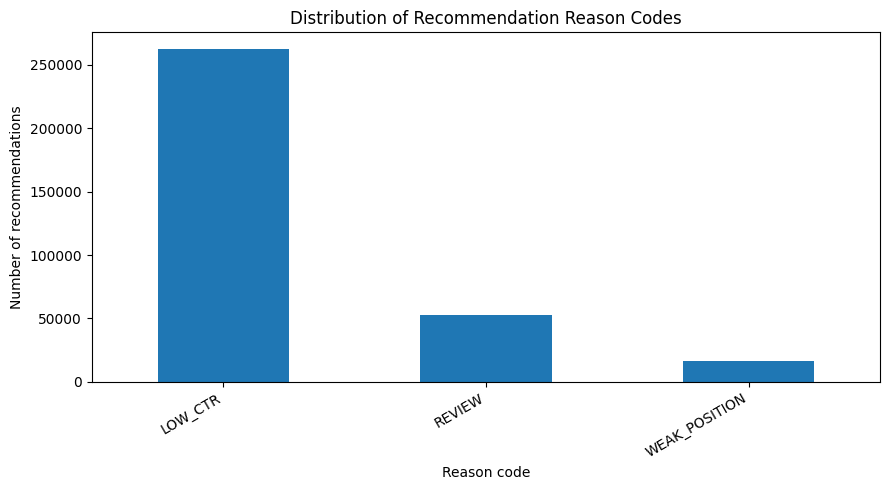

Saved: /content/work/outputs/paper_reason_code_distribution.png


In [28]:
# Figure 2: distribution of reason codes

if "reason_code" in action_queue.columns:
    reason_counts = action_queue["reason_code"].value_counts()

    plt.figure(figsize=(9, 5))
    reason_counts.plot(kind="bar")

    plt.title("Distribution of Recommendation Reason Codes")
    plt.xlabel("Reason code")
    plt.ylabel("Number of recommendations")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    reason_fig_path = os.path.join(
        output_dir,
        "paper_reason_code_distribution.png"
    )

    plt.savefig(reason_fig_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", reason_fig_path)

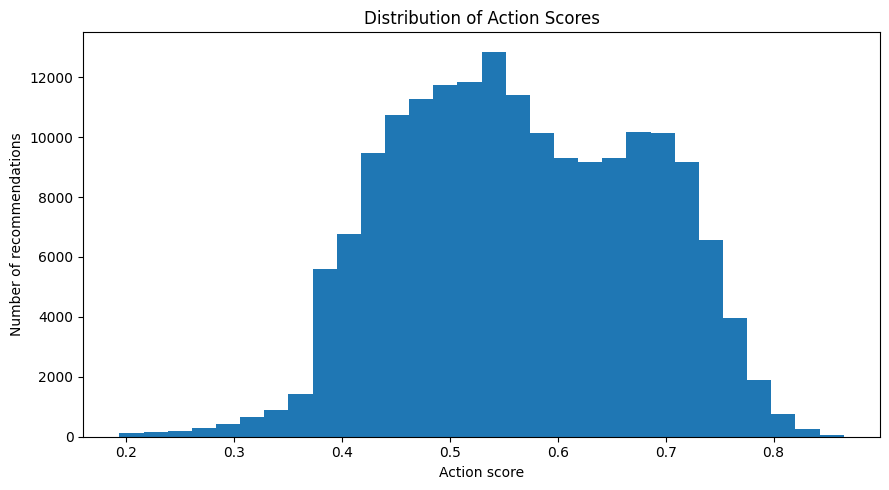

Saved: /content/work/outputs/paper_action_score_distribution.png


In [29]:
# Figure 3: action-score distribution

if "action_score" in action_queue.columns:
    plt.figure(figsize=(9, 5))

    plt.hist(
        action_queue["action_score"].dropna(),
        bins=30
    )

    plt.title("Distribution of Action Scores")
    plt.xlabel("Action score")
    plt.ylabel("Number of recommendations")
    plt.tight_layout()

    score_fig_path = os.path.join(
        output_dir,
        "paper_action_score_distribution.png"
    )

    plt.savefig(score_fig_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", score_fig_path)

In [30]:
print("=== PAPER ARTIFACTS ===")

for filename in sorted(os.listdir(output_dir)):
    if (
        filename.endswith(".csv")
        or filename.endswith(".png")
        or filename.endswith(".json")
    ):
        path = os.path.join(output_dir, filename)
        print(f"{filename:45s} {os.path.getsize(path):,} bytes")

=== PAPER ARTIFACTS ===
action_playbook_queue.csv                     57,285,795 bytes
paper_action_distribution.png                 77,384 bytes
paper_action_score_distribution.png           53,655 bytes
paper_reason_code_distribution.png            77,779 bytes
paper_top20_recommendations.csv               1,764 bytes


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.